In [58]:
# import gurobipy as gp
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.io as pio
import numpy as np
import pandas as pd

Loading Network

In [59]:
def load_edges_from_csv(path_edges: str):
    """
    CSV esperado: node_id1,node_id2,b,f_max
    b = costo base por arco
    f_max = capacidad base
    """
    edges = pd.read_csv(path_edges)
    edges = edges.rename(columns={
        "node_id1": "i",
        "node_id2": "j",
        "b": "c_base",
        "f_max": "U_base"
    })

    edges["e_id"] = np.arange(len(edges))
    return edges

def load_nodes_from_csv(path_nodes: str):
    """
    CSV esperado:
    node_id,d,p_min,p_max,c_var,is_generator,energy_type,instance
    d = demanda base (si no es generador)
    p_max = capacidad gen máxima (si es generador)
    """
    nodes = pd.read_csv(path_nodes)
    nodes = nodes.rename(columns={"node_id":"node"})
    return nodes

Defining the world $W$, the baseline for scenarios

In [60]:
def sample_one_scenario_W(nodes, edges, rng,
                          p_crisis=0.15,
                          # mediocristan
                          dem_sigma=0.10,
                          cost_sigma=0.05,
                          p_outage=0.2,
                          cap_drop=0.45,
                          # extremistan
                          crisis_dem_mult_mu=2.0,
                          crisis_dem_mult_sigma=0.25,
                          crisis_cost_mult=1.25,
                          correlated_outage_nodes=None,
                          correlated_outage_prob=0.8):

    # 1) Crisis o no
    crisis = rng.random() < p_crisis

    # 2) Demanda por nodo: D_iω
    D = nodes[["node"]].copy()
    D["D_base"] = nodes["d"].fillna(0.0)

    if not crisis:
        mult = rng.normal(1.0, dem_sigma, size=len(D))
        mult = np.clip(mult, 0.0, None)
    else:
        pareto_alpha = 2.0
        Y = rng.pareto(a=pareto_alpha, size=len(D))
        mult = 1.0 + Y

    D["D_w"] = D["D_base"] * mult
    D.loc[D["D_base"] == 0, "D_w"] = 0.0

    # 3) Costo por arco: c_eω
    c = edges[["e_id", "c_base"]].copy()

    if not crisis:
        cost_mult = rng.normal(1.0, cost_sigma, size=len(c))
        cost_mult = np.clip(cost_mult, 0.1, None)
    else:
        cost_mult = np.ones(len(c)) * crisis_cost_mult
    c["c_w"] = c["c_base"] * cost_mult

    # 4) Capacidad por arco: U_eω
    U = edges[["e_id", "U_base", "i", "j"]].copy()

    outage = rng.random(len(U)) < p_outage
    U_mult = np.where(outage, cap_drop, 1.0)

    if crisis and correlated_outage_nodes is not None:
        if rng.random() < correlated_outage_prob:
            affected = U["i"].isin(correlated_outage_nodes) | U["j"].isin(correlated_outage_nodes)
            U_mult = np.where(affected, 0.0, U_mult)

    U["U_w"] = U["U_base"] * U_mult

    # 5) Capacidad de generación por nodo: G_iω  ← NUEVO
    G = nodes[["node"]].copy()
    G["G_base"] = nodes["p_max"].fillna(0.0)

    if not crisis:
        gen_mult = rng.normal(1.0, 0.05, size=len(G))
        gen_mult = np.clip(gen_mult, 0.5, 1.0)
    else:
        gen_mult = rng.uniform(0.3, 1.0, size=len(G))

    G["G_w"] = G["G_base"] * gen_mult
    G.loc[G["G_base"] == 0, "G_w"] = 0.0  # nodos de demanda no generan

    return {
        "crisis": int(crisis),
        "D": D[["node", "D_w"]],
        "U": U[["e_id", "U_w"]],
        "c": c[["e_id", "c_w"]],
        "G": G[["node", "G_w"]],   # ← NUEVO
    }

Montecarlo simulation

In [61]:

def generate_massive_W(nodes, edges, n_samples=1000, seed=123,
                       correlated_outage_nodes=None):
    rng = np.random.default_rng(seed)
    scenarios = []
    for _ in range(n_samples):
        sc = sample_one_scenario_W(nodes, edges, rng,
                                   correlated_outage_nodes=correlated_outage_nodes)
        scenarios.append(sc)
    return scenarios


Clustering process

In [62]:
def scenario_features(sc, nodes, edges):
    """
    Convierte escenario a un vector feature para cluster:
    - demanda total
    - % capacidad perdida (promedio)
    - costo medio
    - indicador crisis
    """
    Dtot = sc["D"]["D_w"].sum()

    U_base = edges.set_index("e_id")["U_base"]
    U_eff  = sc["U"].set_index("e_id")["U_w"]
    cap_loss = 1.0 - (U_eff / U_base.replace(0, np.nan)).fillna(1.0)
    cap_loss_mean = cap_loss.mean()

    c_mean = sc["c"]["c_w"].mean()

    return np.array([Dtot, cap_loss_mean, c_mean, sc["crisis"]], dtype=float)

def reduce_to_K_scenarios(scenarios, nodes, edges, K=20, seed=123):
    """
    Reducción simple:
    - extrae features
    - aplica k-means
    - elige como representante el escenario más cercano al centroide (medoid)
    - prob de cada escenario = proporción de puntos asignados
    """
    from sklearn.cluster import KMeans

    X = np.vstack([scenario_features(sc, nodes, edges) for sc in scenarios])
    km = KMeans(n_clusters=K, random_state=seed, n_init=20)
    labels = km.fit_predict(X)
    centers = km.cluster_centers_

    reps = []
    probs = []
    #encontrar representante de cada cluster
    for k in range(K):
        idx = np.where(labels == k)[0]
        probs.append(len(idx) / len(scenarios))
        # elegir el más cercano al centroide
        dists = np.linalg.norm(X[idx] - centers[k], axis=1)
        rep_idx = idx[np.argmin(dists)]
        reps.append(scenarios[rep_idx])

    return reps, np.array(probs)

In [63]:
def export_Wprime(reps, probs, out_prefix="Wprime"):
    """
    Crea tres tablas:
    - demanda: (omega, node, D_iw)
    - capacidad: (omega, e_id, U_ew)
    - costos: (omega, e_id, c_ew)
    - prob: (omega, p_omega, crisis)
    """
    rows_D, rows_U, rows_c, rows_p, rows_G = [], [], [], [], []

    for w, (sc, p) in enumerate(zip(reps, probs), start=1):
        rows_p.append({"omega": w, "p_omega": float(p), "crisis": sc["crisis"]})

        for _, r in sc["D"].iterrows():
            rows_D.append({"omega": w, "node": int(r["node"]), "D_iw": float(r["D_w"])})
        for _, r in sc["U"].iterrows():
            rows_U.append({"omega": w, "e_id": int(r["e_id"]), "U_ew": float(r["U_w"])})
        for _, r in sc["c"].iterrows():
            rows_c.append({"omega": w, "e_id": int(r["e_id"]), "c_ew": float(r["c_w"])})
        for _, r in sc["G"].iterrows():
            rows_G.append({"omega": w, "node": int(r["node"]), "G_iw": float(r["G_w"])})

    dfD = pd.DataFrame(rows_D)
    dfU = pd.DataFrame(rows_U)
    dfc = pd.DataFrame(rows_c)
    dfp = pd.DataFrame(rows_p)
    dfG = pd.DataFrame(rows_G)

    dfD.to_csv(f"{out_prefix}_D.csv", index=False)
    dfU.to_csv(f"{out_prefix}_U.csv", index=False)
    dfc.to_csv(f"{out_prefix}_c.csv", index=False)
    dfp.to_csv(f"{out_prefix}_p.csv", index=False)
    dfG.to_csv(f"{out_prefix}_G.csv", index=False)

    return dfD, dfU, dfc, dfp, dfG


In [64]:
edges = load_edges_from_csv("edges.csv")
nodes = load_nodes_from_csv("nodes.csv")

instance = 60
nodes = nodes[nodes["instance"] == instance].reset_index(drop=True)
gens = nodes[nodes["is_generator"] == True]["node"].to_list()

print("Instancia elegida:", instance)
print("nodos totales:", len(nodes))
print("generadores:", gens)
print("Tipo de energía para la instancia", instance, ":")
print(nodes.groupby("energy_type")["node"].count())

# 1) W masivo
escenarios_W = generate_massive_W(nodes, edges, n_samples=1000, seed=1,
                                  correlated_outage_nodes=gens)

# 2) Reducir a 20 escenarios
reps, probs = reduce_to_K_scenarios(escenarios_W, nodes, edges, K=20, seed=1)

# 3) Exportar — ahora retorna 5 valores (dfG es nuevo)
dfD, dfU, dfc, dfp, dfG = export_Wprime(reps, probs, out_prefix="Wprime20")

Instancia elegida: 60
nodos totales: 118
generadores: [9, 11, 24, 25, 30, 45, 48, 53, 58, 60, 64, 65, 79, 86, 88, 99, 102, 110]
Tipo de energía para la instancia 60 :
energy_type
coal     4
gas      6
hydro    2
solar    4
wind     2
Name: node, dtype: int64


In [65]:
# nodes
# dfD[dfD["omega"]==1]
dfp["p_omega"].sum()

np.float64(1.0)

Gráficos

In [66]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.patches import Patch

omegas_list = dfp["omega"].tolist()
p_vals      = dfp["p_omega"].values
crisis_vals = dfp["crisis"].values
colors      = ["#c0392b" if c else "#2980b9" for c in crisis_vals]
labels      = [f"ω{w}" for w in omegas_list]

D_total   = dfD.groupby("omega")["D_iw"].sum().reindex(omegas_list).values
c_mean_sc = dfc.groupby("omega")["c_ew"].mean().reindex(omegas_list).values
G_total   = dfG.groupby("omega")["G_iw"].sum().reindex(omegas_list).values
deficit   = D_total - G_total

U_base_series = edges.set_index("e_id")["U_base"]
cap_loss_mean, arcos_caidos, arcos_debil = [], [], []
for w in omegas_list:
    U_sc  = dfU[dfU["omega"] == w].set_index("e_id")["U_ew"]
    ratio = (U_sc / U_base_series.replace(0, np.nan)).fillna(1.0)
    loss  = 1.0 - ratio
    cap_loss_mean.append(loss.mean())
    arcos_caidos.append((U_sc == 0).sum())
    arcos_debil.append(((U_sc > 0) & (U_sc < U_base_series)).sum())

cap_loss_mean = np.array(cap_loss_mean)
arcos_caidos  = np.array(arcos_caidos)
arcos_debil   = np.array(arcos_debil)

legend_elements = [
    Patch(facecolor="#c0392b", label="Crisis (Extremistán)"),
    Patch(facecolor="#2980b9", label="Normal (Mediocristán)"),
]

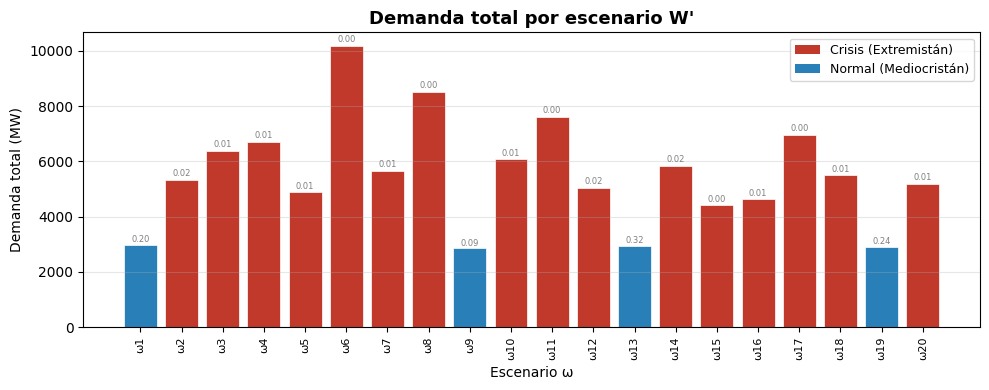

In [67]:
# Demanda total por escenario

fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.bar(labels, D_total, color=colors, edgecolor="white", linewidth=0.5)
for bar, p in zip(bars, p_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f"{p:.2f}", ha="center", va="bottom", fontsize=6, color="gray")

ax.set_title("Demanda total por escenario W'", fontsize=13, fontweight="bold")
ax.set_ylabel("Demanda total (MW)")
ax.set_xlabel("Escenario ω")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

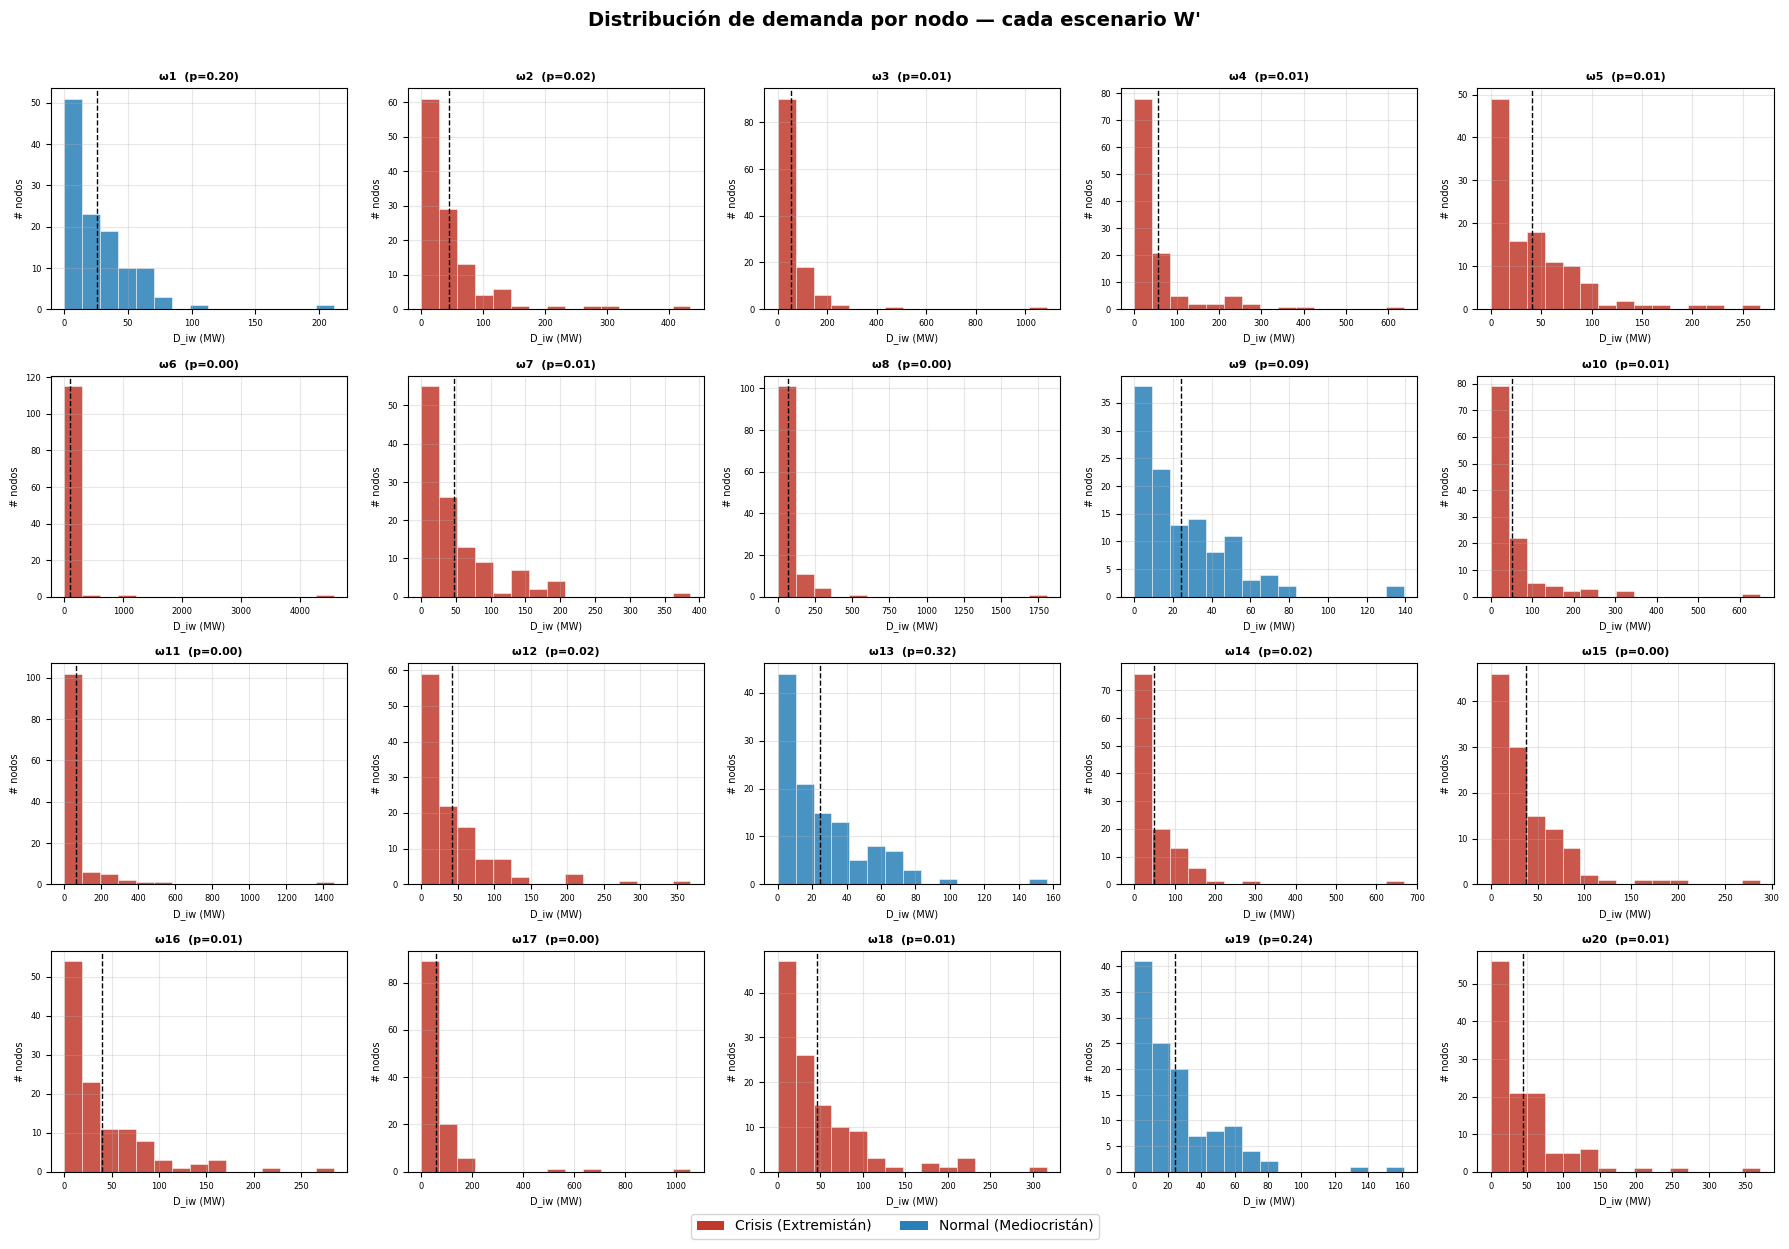

In [68]:
#Demanda

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

for idx, w in enumerate(omegas_list):
    ax = axes[idx]
    vals = dfD[dfD["omega"] == w]["D_iw"].values
    crisis = dfp[dfp["omega"] == w]["crisis"].values[0]
    color  = "#c0392b" if crisis else "#2980b9"

    ax.hist(vals, bins=15, color=color, edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1)
    ax.set_title(f"ω{w}  (p={p_vals[idx]:.2f})", fontsize=8, fontweight="bold")
    ax.set_xlabel("D_iw (MW)", fontsize=7)
    ax.set_ylabel("# nodos", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.3)

fig.suptitle("Distribución de demanda por nodo — cada escenario W'",
             fontsize=14, fontweight="bold", y=1.01)
fig.legend(handles=legend_elements, loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

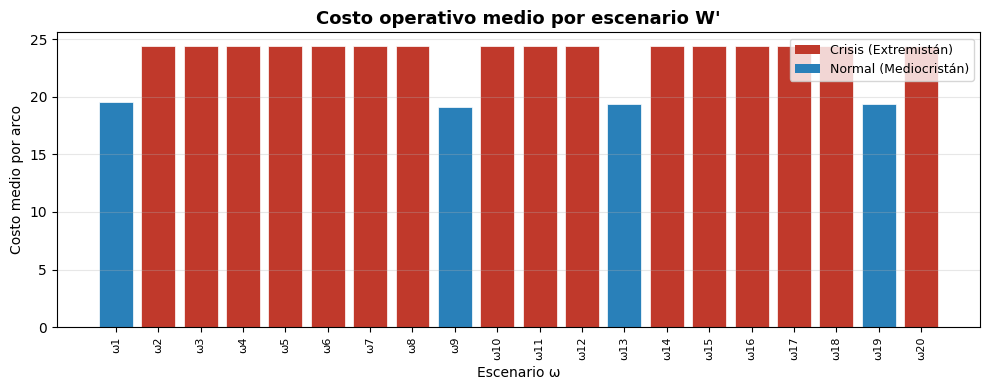

In [69]:
# Costo operativo medio por escenario

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(labels, c_mean_sc, color=colors, edgecolor="white", linewidth=0.5)
ax.set_title("Costo operativo medio por escenario W'", fontsize=13, fontweight="bold")
ax.set_ylabel("Costo medio por arco")
ax.set_xlabel("Escenario ω")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

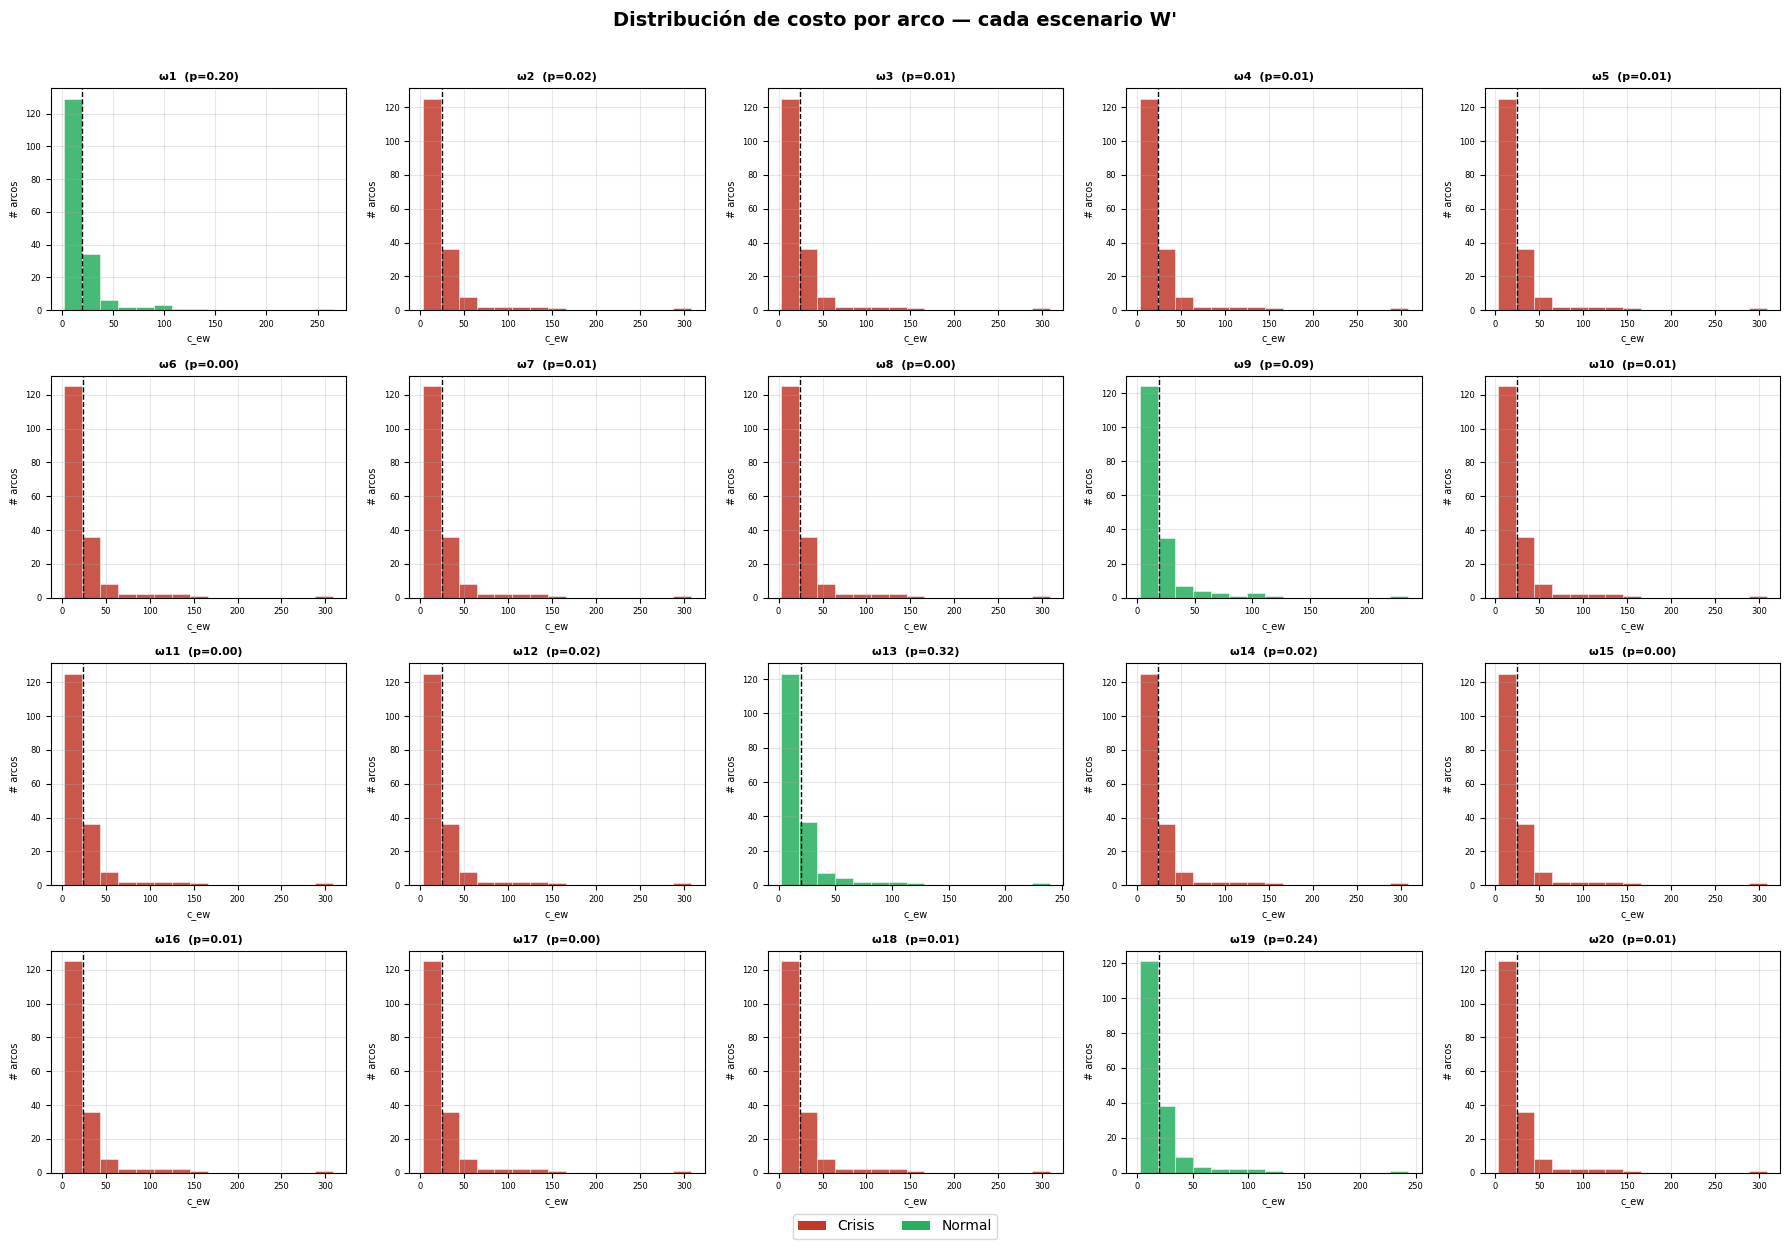

In [70]:
# Costo por escenario

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

for idx, w in enumerate(omegas_list):
    ax = axes[idx]
    vals = dfc[dfc["omega"] == w]["c_ew"].values
    crisis = dfp[dfp["omega"] == w]["crisis"].values[0]
    color  = "#c0392b" if crisis else "#27ae60"

    ax.hist(vals, bins=15, color=color, edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1)
    ax.set_title(f"ω{w}  (p={p_vals[idx]:.2f})", fontsize=8, fontweight="bold")
    ax.set_xlabel("c_ew", fontsize=7)
    ax.set_ylabel("# arcos", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.3)

fig.suptitle("Distribución de costo por arco — cada escenario W'",
             fontsize=14, fontweight="bold", y=1.01)
cost_legend = [Patch(facecolor="#c0392b", label="Crisis"),
               Patch(facecolor="#27ae60", label="Normal")]
fig.legend(handles=cost_legend, loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

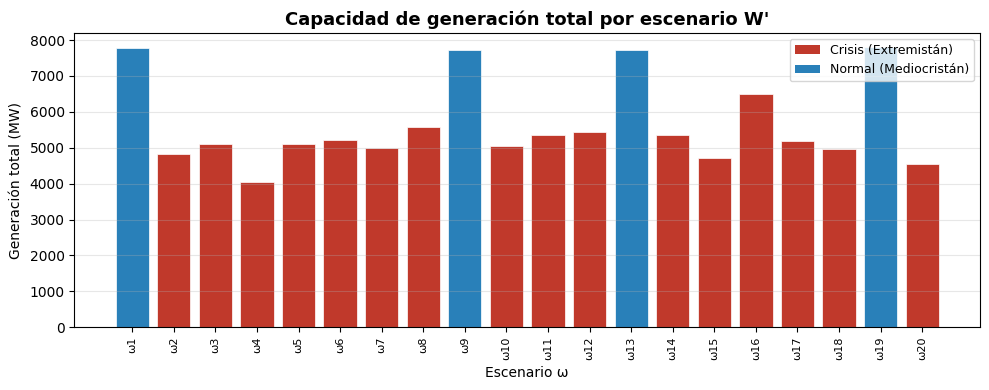

In [71]:
# Capacidad por escenario
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(labels, G_total, color=colors, edgecolor="white", linewidth=0.5)
ax.set_title("Capacidad de generación total por escenario W'", fontsize=13, fontweight="bold")
ax.set_ylabel("Generación total (MW)")
ax.set_xlabel("Escenario ω")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

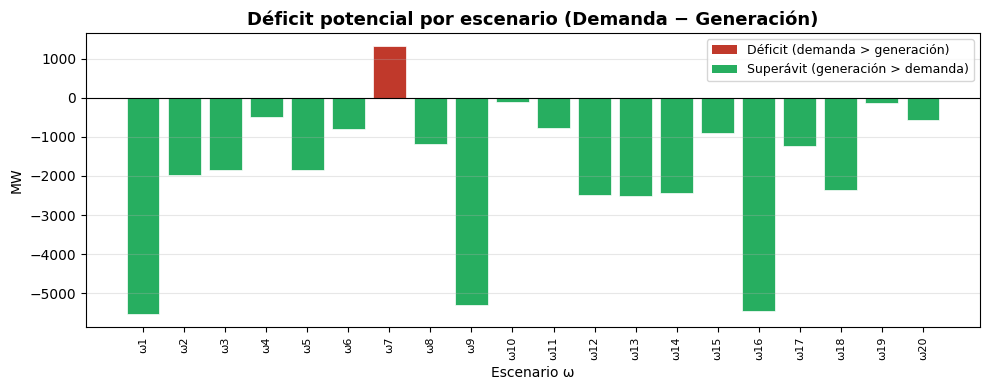

In [ ]:
# Deficit potencial por escenario

fig, ax = plt.subplots(figsize=(10, 4))

deficit_colors = ["#c0392b" if d > 0 else "#27ae60" for d in deficit]
ax.bar(labels, deficit, color=deficit_colors, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8)

ax.set_title("Déficit potencial por escenario (Demanda - Generación)", fontsize=13, fontweight="bold")
ax.set_ylabel("MW")
ax.set_xlabel("Escenario ω")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.grid(axis="y", alpha=0.3)

deficit_legend = [
    Patch(facecolor="#c0392b", label="Déficit (demanda > generación)"),
    Patch(facecolor="#27ae60", label="Superávit (generación > demanda)"),
]
ax.legend(handles=deficit_legend, fontsize=9)
plt.tight_layout()
plt.show()

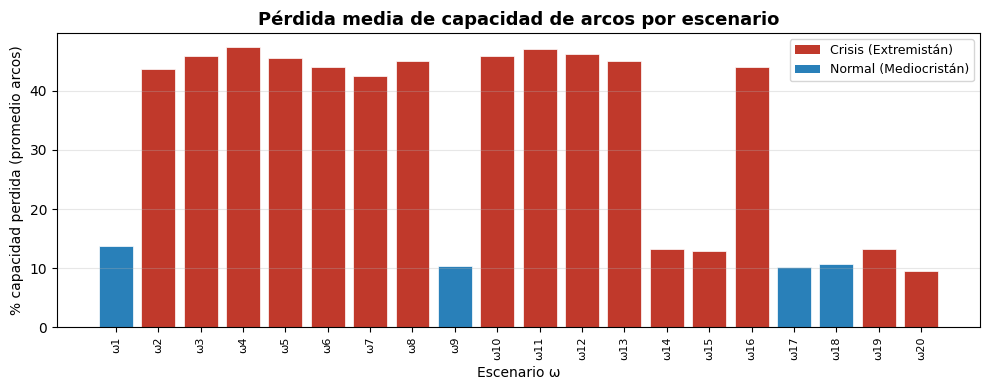

In [30]:
# Pérdida de capacidad por escenario

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(labels, cap_loss_mean * 100, color=colors, edgecolor="white", linewidth=0.5)
ax.set_title("Pérdida media de capacidad de arcos por escenario", fontsize=13, fontweight="bold")
ax.set_ylabel("% capacidad perdida (promedio arcos)")
ax.set_xlabel("Escenario ω")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

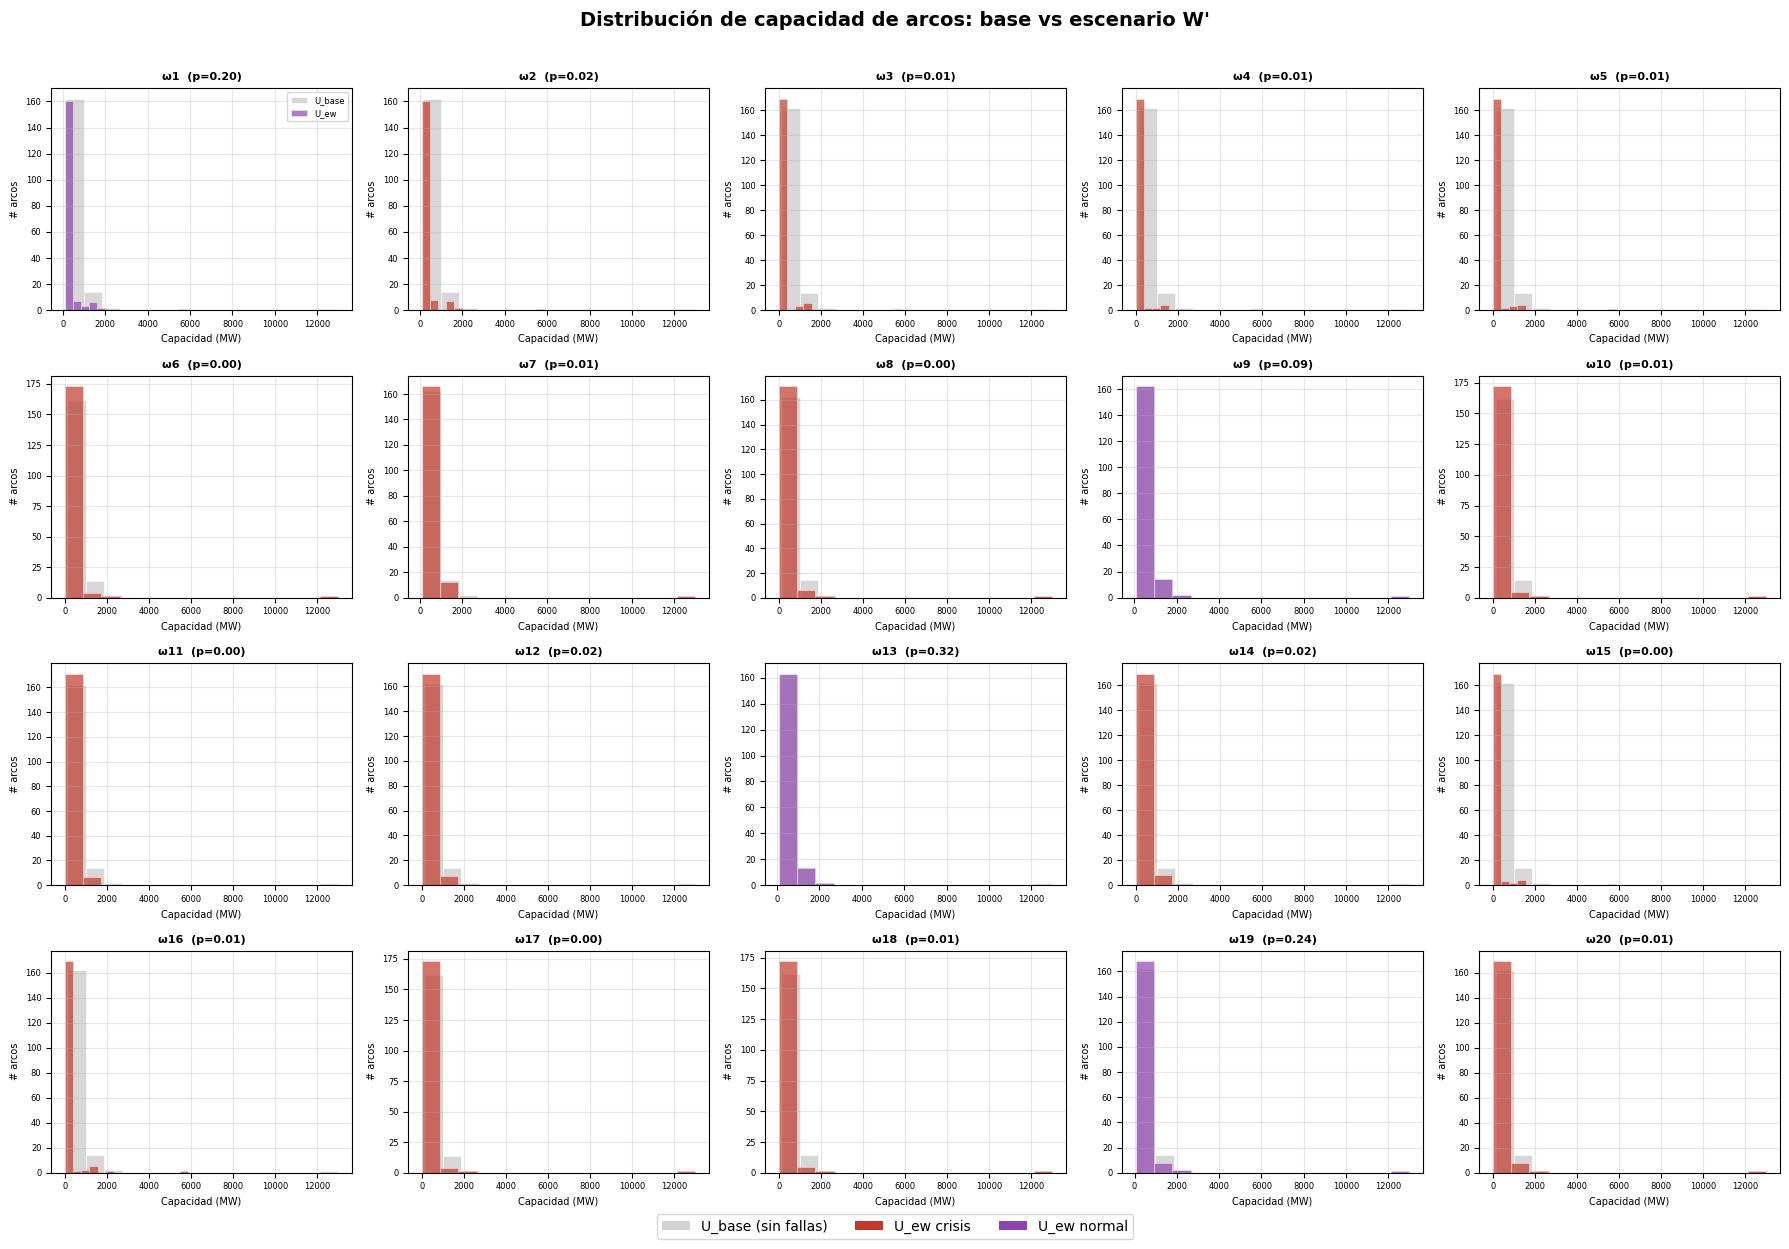

In [72]:
# Capacidad de arcos

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

for idx, w in enumerate(omegas_list):
    ax = axes[idx]
    vals      = dfU[dfU["omega"] == w]["U_ew"].values
    vals_base = U_base_series.values
    crisis    = dfp[dfp["omega"] == w]["crisis"].values[0]
    color     = "#c0392b" if crisis else "#8e44ad"

    ax.hist(vals_base, bins=15, color="lightgray", edgecolor="white",
            linewidth=0.4, alpha=0.9, label="U_base")
    ax.hist(vals, bins=15, color=color, edgecolor="white",
            linewidth=0.4, alpha=0.7, label="U_ew")
    ax.set_title(f"ω{w}  (p={p_vals[idx]:.2f})", fontsize=8, fontweight="bold")
    ax.set_xlabel("Capacidad (MW)", fontsize=7)
    ax.set_ylabel("# arcos", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.3)

# leyenda solo en primer subplot
axes[0].legend(fontsize=6)

fig.suptitle("Distribución de capacidad de arcos: base vs escenario W'",
             fontsize=14, fontweight="bold", y=1.01)
cap_legend = [Patch(facecolor="lightgray", label="U_base (sin fallas)"),
              Patch(facecolor="#c0392b", label="U_ew crisis"),
              Patch(facecolor="#8e44ad", label="U_ew normal")]
fig.legend(handles=cap_legend, loc="lower center",
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

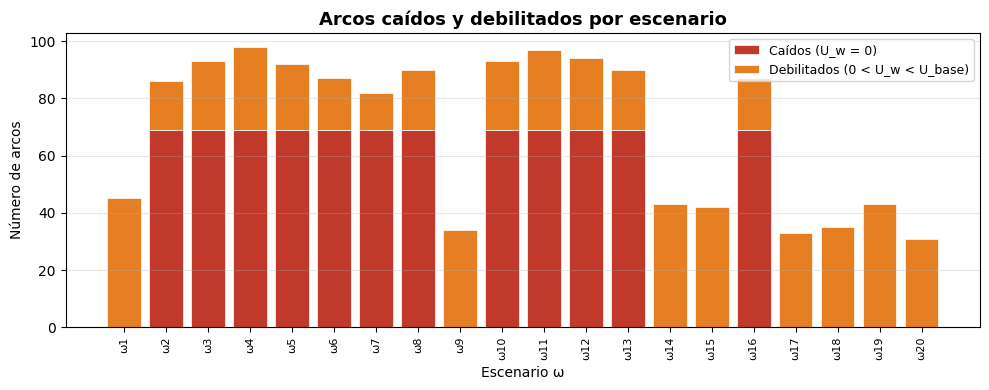

In [32]:
# Arcos caídos vs. debilitados

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(labels, arcos_caidos, label="Caídos (U_w = 0)",
       color="#c0392b", edgecolor="white", linewidth=0.5)
ax.bar(labels, arcos_debil, bottom=arcos_caidos,
       label="Debilitados (0 < U_w < U_base)",
       color="#e67e22", edgecolor="white", linewidth=0.5)

ax.set_title("Arcos caídos y debilitados por escenario", fontsize=13, fontweight="bold")
ax.set_ylabel("Número de arcos")
ax.set_xlabel("Escenario ω")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

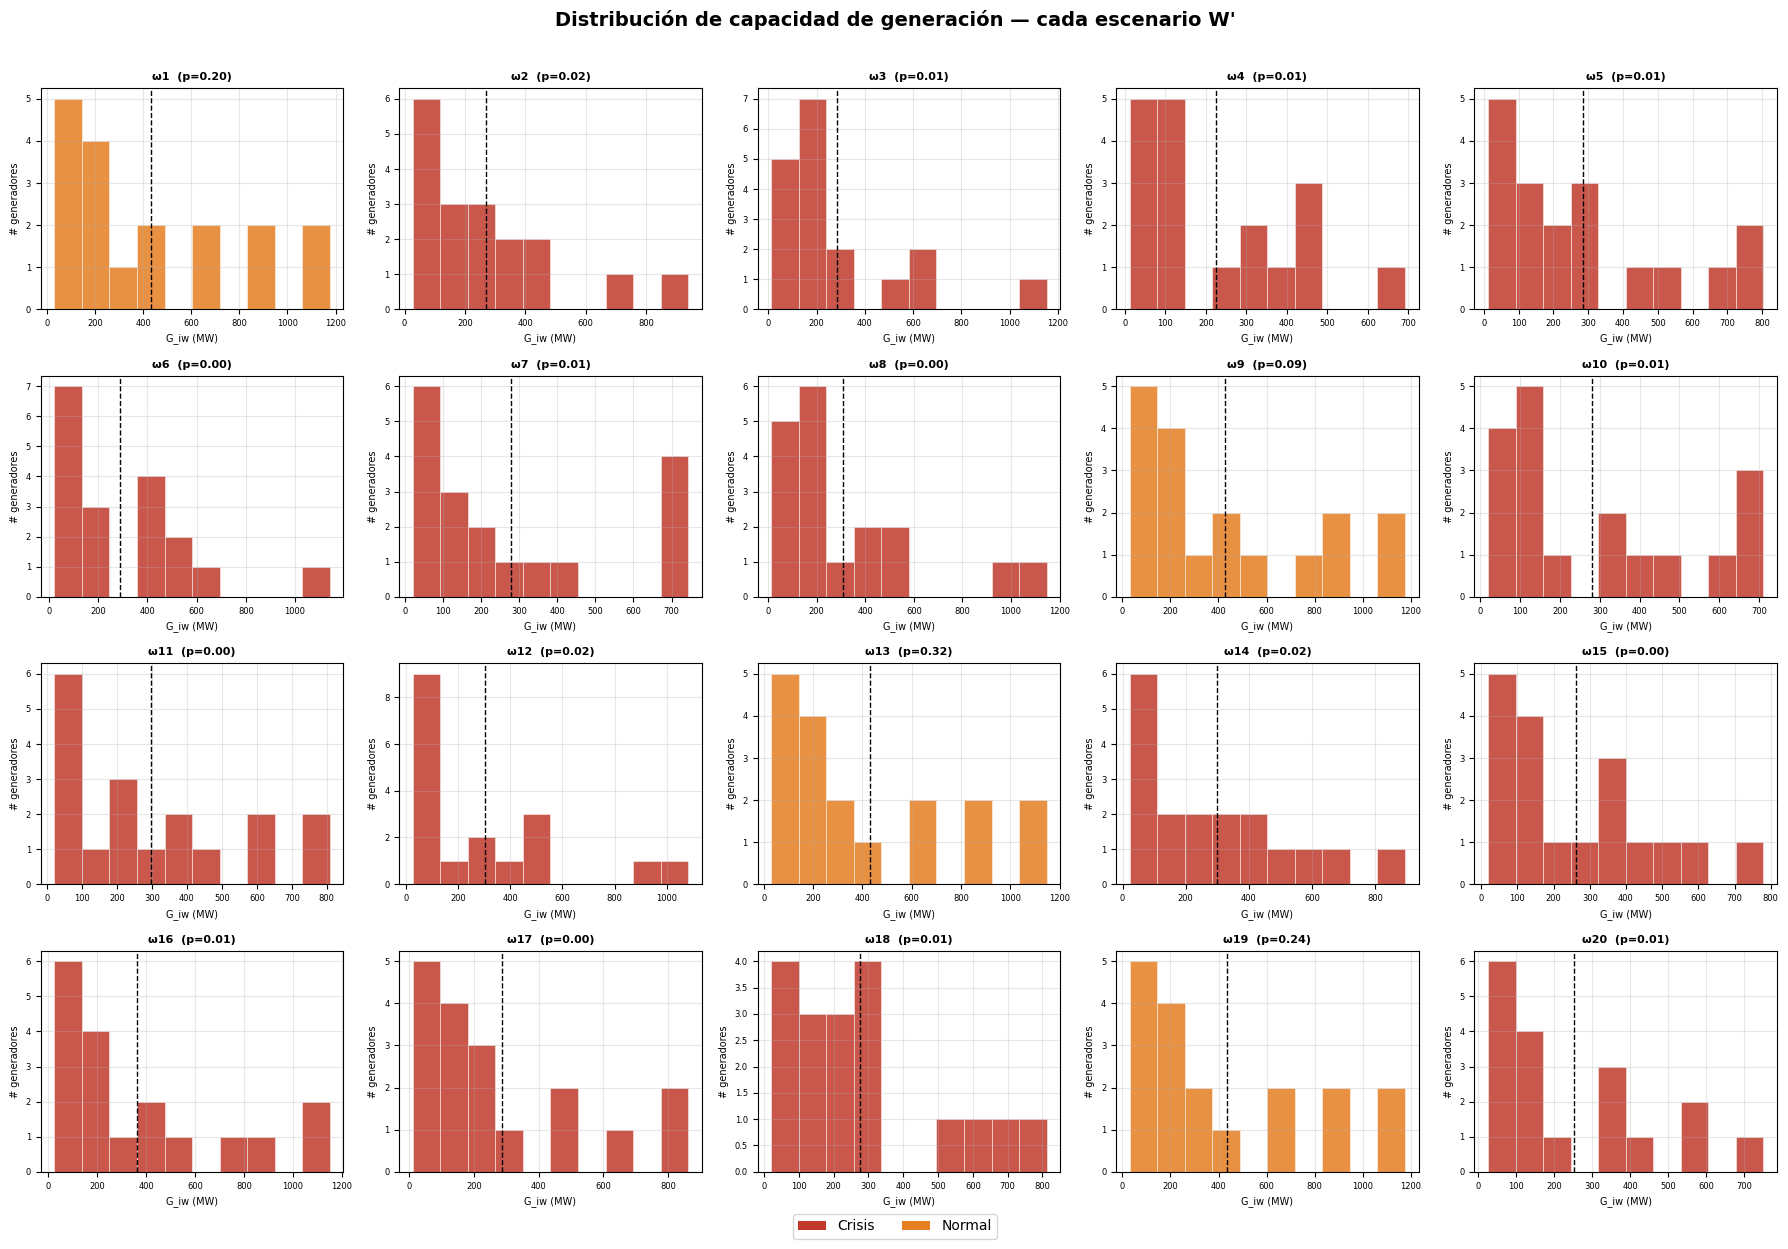

In [73]:
# Generación

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

# solo nodos generadores
gen_nodes_list = nodes[nodes["is_generator"] == True]["node"].tolist()

for idx, w in enumerate(omegas_list):
    ax = axes[idx]
    # solo filas de generadores
    vals = dfG[(dfG["omega"] == w) & (dfG["node"].isin(gen_nodes_list))]["G_iw"].values
    crisis = dfp[dfp["omega"] == w]["crisis"].values[0]
    color  = "#c0392b" if crisis else "#e67e22"

    ax.hist(vals, bins=10, color=color, edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1)
    ax.set_title(f"ω{w}  (p={p_vals[idx]:.2f})", fontsize=8, fontweight="bold")
    ax.set_xlabel("G_iw (MW)", fontsize=7)
    ax.set_ylabel("# generadores", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.3)

fig.suptitle("Distribución de capacidad de generación — cada escenario W'",
             fontsize=14, fontweight="bold", y=1.01)
gen_legend = [Patch(facecolor="#c0392b", label="Crisis"),
              Patch(facecolor="#e67e22", label="Normal")]
fig.legend(handles=gen_legend, loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

Distribuciones